### Simple

In [1]:
# Source:  https://github.com/cobriant/inverse_reinforcement_learning/blob/main/example1.R

import numpy as np
from scipy.linalg import inv
from scipy.optimize import linprog

# Transition probability array p_ssa: states x states x actions
# action 1: stay; action 2: randomize; action 3: switch

# Data from the R code, adjusted for column-major order
p_ssa_data = [
    # Action 1
    1, 0,  # p_ssa[0,0,0], p_ssa[1,0,0]
    0, 1,  # p_ssa[0,1,0], p_ssa[1,1,0]
    # Action 2
    0.5, 0.5,  # p_ssa[0,0,1], p_ssa[1,0,1]
    0.5, 0.5,  # p_ssa[0,1,1], p_ssa[1,1,1]
    # Action 3
    0, 1,  # p_ssa[0,0,2], p_ssa[1,0,2]
    1, 0   # p_ssa[0,1,2], p_ssa[1,1,2]
]

# Reshape with order='F' to match R's column-major order
p_ssa = np.array(p_ssa_data).reshape((2, 2, 3), order='F')
print("p_ssa:")
print(p_ssa)

# Upper bound for reward function
Rmax = 10

# Optimal policy: stay in state 1, switch in state 2
optimal_p = [0, 2]  # Corresponds to actions 1 and 3 in R

# Transition matrix under the optimal policy p_a1
p_a1 = np.vstack((p_ssa[0, :, optimal_p[0]], p_ssa[1, :, optimal_p[1]]))
print("\np_a1:")
print(p_a1)

n = p_ssa.shape[0]  # Number of states (2)
k = p_ssa.shape[2]  # Number of actions (3)
beta = 0.9

# Compute inverse of (I - beta * p_a1)
inv_matrix = inv(np.eye(n) - beta * p_a1)

# Function to compute the drop in value from choosing action 'a' in state 'i'
def drop_in_v(a, i):
    delta_p = p_a1[i, :] - p_ssa[i, :, a]
    return delta_p @ inv_matrix

# Compute and print drop_in_v values
print("\nComputed drop_in_v values:")
for i in range(n):
    for a in range(k):
        div = drop_in_v(a, i)
        print(f"drop_in_v(a={a+1}, i={i+1}): {div}")

# Variables: x = [z_1, z_2, R_1, R_2]
# Objective: maximize sum of z_i (linprog minimizes, so we use negative)
c = -np.array([1, 1, 0, 0])

# Initialize lists to build A_ub and b_ub
A_ub = []
b_ub = []

# First set of constraints: z_i - drop_in_v(a, i) * R <= 0
for i in range(n):
    for a in range(k):
        if a != optimal_p[i]:
            row = [0] * (n + n)
            row[i] = 1  # Coefficient for z_i
            drop = drop_in_v(a, i)
            row[n:] = -drop  # Coefficients for R_i
            A_ub.append(row)
            b_ub.append(0)

# Second set of constraints: -drop_in_v(a, i) * R <= 0
for i in range(n):
    for a in range(k):
        row = [0] * (n + n)
        drop = drop_in_v(a, i)
        row[n:] = -drop  # Coefficients for R_i
        A_ub.append(row)
        b_ub.append(0)

# Third set of constraints: R_i <= Rmax
for i in range(n):
    row = [0] * (n + n)
    row[n + i] = 1  # Coefficient for R_i
    A_ub.append(row)
    b_ub.append(Rmax)

# Convert to numpy arrays
A_ub = np.array(A_ub)
b_ub = np.array(b_ub)

# Variable bounds: x >= 0
bounds = [(0, None)] * (n + n)

# Solve the linear programming problem
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

# Check if the optimization was successful
if res.success:
    print("\nOptimal solution found:")
    z = res.x[:n]
    R = res.x[n:]
    print("z_i values:", z)
    print("R_i values:", R)
else:
    print("Optimization failed:", res.message)

# Value function V = (I - beta * p_a1)^{-1} * R
V = inv_matrix @ R
print("\nValue function V:")
print(V)


p_ssa:
[[[1.  0.5 0. ]
  [0.  0.5 1. ]]

 [[0.  0.5 1. ]
  [1.  0.5 0. ]]]

p_a1:
[[1. 0.]
 [1. 0.]]

Computed drop_in_v values:
drop_in_v(a=1, i=1): [0. 0.]
drop_in_v(a=2, i=1): [ 0.5 -0.5]
drop_in_v(a=3, i=1): [ 1. -1.]
drop_in_v(a=1, i=2): [ 1. -1.]
drop_in_v(a=2, i=2): [ 0.5 -0.5]
drop_in_v(a=3, i=2): [0. 0.]

Optimal solution found:
z_i values: [5. 5.]
R_i values: [10.  0.]

Value function V:
[100.  90.]


In [2]:
import numpy as np
from scipy.linalg import inv
from scipy.optimize import linprog
import matplotlib.pyplot as plt

def finite_lp_irl(num_states, num_actions, transition_probabilities,
                                   discount_factor, max_reward, optimal_policy, regularization=0.0):
    """
    Perform Inverse Reinforcement Learning to estimate the reward function.

    Args:
        num_states (int): Number of states in the MDP.
        num_actions (int): Number of actions available in each state.
        transition_probabilities (np.ndarray): Transition probabilities tensor with shape (S, S, A).
        discount_factor (float): Discount factor gamma (0 < gamma < 1).
        max_reward (float): Upper bound on the reward function values.
        optimal_policy (np.ndarray): Optimal policy array of shape (S,).
        regularization (float): Regularization coefficient lambda.

    Returns:
        tuple: Estimated reward function (R_est) and value function (V_est).
    """
    # Compute the transition matrix under the optimal policy
    P_opt = np.vstack([
        transition_probabilities[s, :, optimal_policy[s]] for s in range(num_states)
    ])

    # Compute the inverse of (I - gamma * P_opt)
    inv_matrix = inv(np.eye(num_states) - discount_factor * P_opt)

    # Function to compute the drop in value from deviating from the optimal policy
    def drop_in_value(action, state):
        delta_p = P_opt[state, :] - transition_probabilities[state, :, action]
        return delta_p @ inv_matrix

    # Problem formulation:
    # Variables: x = [z_1, z_2, ..., z_S, R_1, R_2, ..., R_S]
    # Objective: Minimize -sum(z_s) + lambda * sum(R_s)
    # Constraints:
    #   1. z_s - drop_in_value(a, s) @ R <= 0, for all s, a != optimal_policy[s]
    #   2. -drop_in_value(a, s) @ R <= 0, for all s, a
    #   3. R_s <= Rmax, for all s
    #   4. z_s >= 0, R_s >= 0, for all s

    num_variables = num_states * 2  # z_s and R_s for each state

    # Objective function coefficients
    c = np.concatenate([
        -np.ones(num_states),           # Coefficients for z_s (maximize sum of z_s)
        regularization * np.ones(num_states)  # Coefficients for R_s (regularization term)
    ])

    # Initialize lists to construct inequality constraints (A_ub x <= b_ub)
    A_ub = []
    b_ub = []

    # Constraint 1: z_s - drop_in_value(a, s) @ R <= 0
    for s in range(num_states):
        for a in range(num_actions):
            if a != optimal_policy[s]:
                row = np.zeros(num_variables)
                row[s] = 1  # Coefficient for z_s
                drop = drop_in_value(a, s)
                row[num_states:] = -drop  # Coefficients for R_s
                A_ub.append(row)
                b_ub.append(0)

    # Constraint 2: -drop_in_value(a, s) @ R <= 0
    for s in range(num_states):
        for a in range(num_actions):
            row = np.zeros(num_variables)
            drop = drop_in_value(a, s)
            row[num_states:] = -drop  # Coefficients for R_s
            A_ub.append(row)
            b_ub.append(0)

    # Constraint 3: R_s <= Rmax
    for s in range(num_states):
        row = np.zeros(num_variables)
        row[num_states + s] = 1  # Coefficient for R_s
        A_ub.append(row)
        b_ub.append(max_reward)

    # Variable bounds: z_s >= 0, R_s >= 0
    bounds = [(0, None)] * num_variables

    # Print problem formulation
    print("Linear Programming Problem Formulation:")
    print("-------------------------------------")
    print(f"Objective Function: Minimize -sum(z_s) + {regularization} * sum(R_s)")
    print("Number of Variables:", num_variables)
    print("Number of Constraints:", len(A_ub))
    print("\nConstraints:")
    print("1. z_s - drop_in_value(a, s) @ R <= 0, for all s, a != optimal_policy[s]")
    print("2. -drop_in_value(a, s) @ R <= 0, for all s, a")
    print(f"3. R_s <= {max_reward}, for all s")
    print("4. z_s >= 0, R_s >= 0, for all s")
    print("-------------------------------------\n")

    # Convert constraints to numpy arrays
    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    # Solve the linear programming problem
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

    # Print solver results
    print("Solver Results:")
    print("---------------")
    if res.success:
        print("Optimization succeeded.")
        print(f"Objective value: {res.fun}")
        print(f"Number of iterations: {res.nit}")
    else:
        print("Optimization failed.")
        print(f"Message: {res.message}")
        raise ValueError("Optimization failed: " + res.message)

    # Extract the estimated rewards and value function
    z_est = res.x[:num_states]
    R_est = res.x[num_states:]

    # Ensure that R_est is bounded by Rmax
    R_est = np.clip(R_est, None, max_reward)

    # Compute the estimated value function
    V_est = inv_matrix @ R_est

    return R_est, V_est

def generate_random_mdp(num_states, num_actions, max_reward):
    """
    Generate a random MDP.

    Args:
        num_states (int): Number of states.
        num_actions (int): Number of actions.
        max_reward (float): Maximum reward value.

    Returns:
        tuple: Reward vector (R_true) and transition probabilities tensor (Pssa).
    """
    # Random rewards between 0 and max_reward
    R_true = np.random.uniform(0, max_reward, size=num_states)

    # Random transition probabilities
    Pssa = np.zeros((num_states, num_states, num_actions))
    for s in range(num_states):
        for a in range(num_actions):
            probabilities = np.random.rand(num_states)
            probabilities /= probabilities.sum()  # Normalize to sum to 1
            Pssa[s, :, a] = probabilities

    return R_true, Pssa

def value_iteration(num_states, num_actions, rewards, transition_probabilities,
                    discount_factor, epsilon=1e-6, max_iterations=1000):
    """
    Perform Value Iteration to compute the optimal policy.

    Args:
        num_states (int): Number of states.
        num_actions (int): Number of actions.
        rewards (np.ndarray): Reward vector of shape (S,).
        transition_probabilities (np.ndarray): Transition probabilities tensor with shape (S, S, A).
        discount_factor (float): Discount factor gamma (0 < gamma < 1).
        epsilon (float): Convergence threshold.
        max_iterations (int): Maximum number of iterations.

    Returns:
        tuple: Optimal value function (V) and optimal policy (policy).
    """
    V = np.zeros(num_states)
    policy = np.zeros(num_states, dtype=int)

    for iteration in range(max_iterations):
        V_prev = V.copy()
        Q = np.zeros((num_states, num_actions))

        for s in range(num_states):
            for a in range(num_actions):
                Q[s, a] = rewards[s] + discount_factor * transition_probabilities[s, :, a] @ V_prev

        V = np.max(Q, axis=1)
        policy = np.argmax(Q, axis=1)

        # Check for convergence
        if np.max(np.abs(V - V_prev)) < epsilon:
            break

    return V, policy

Linear Programming Problem Formulation:
-------------------------------------
Objective Function: Minimize -sum(z_s) + 0.1 * sum(R_s)
Number of Variables: 20
Number of Constraints: 200

Constraints:
1. z_s - drop_in_value(a, s) @ R <= 0, for all s, a != optimal_policy[s]
2. -drop_in_value(a, s) @ R <= 0, for all s, a
3. R_s <= 10.0, for all s
4. z_s >= 0, R_s >= 0, for all s
-------------------------------------

Solver Results:
---------------
Optimization succeeded.
Objective value: -3.0405702527322616
Number of iterations: 30


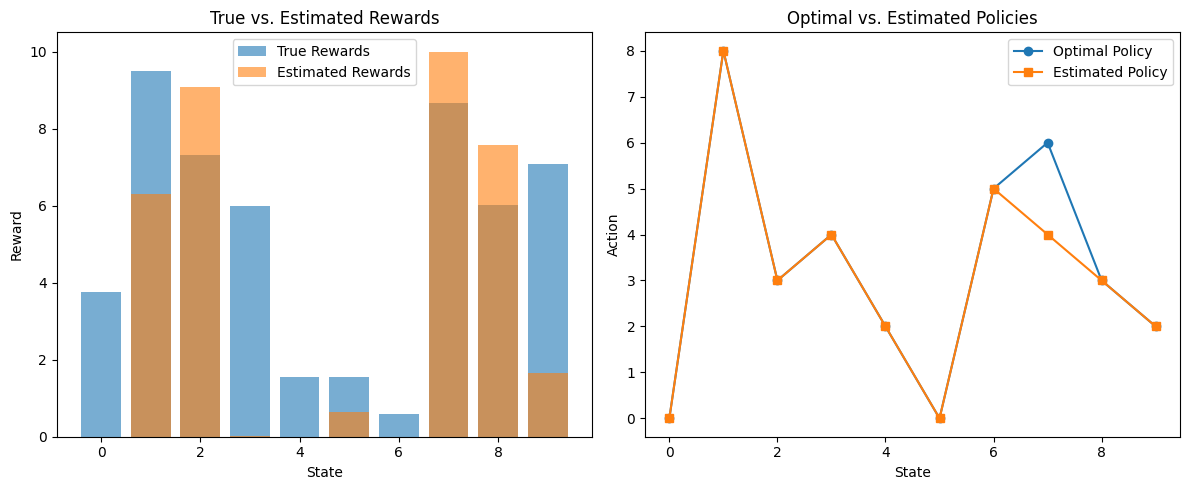

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# MDP parameters
num_states = 10
num_actions = 10
discount_factor = 0.9
max_reward = 10.0
regularization = 0.1  # Regularization coefficient lambda

# Set random seed for reproducibility
np.random.seed(42)

# Generate a random MDP
R_true, Pssa = generate_random_mdp(num_states, num_actions, max_reward)

# Compute the optimal policy using Value Iteration
V_opt, policy_opt = value_iteration(num_states, num_actions, R_true, Pssa, discount_factor)

# Perform Inverse Reinforcement Learning to estimate the reward function
R_est, V_est = finite_lp_irl(
    num_states, num_actions, Pssa, discount_factor, max_reward, policy_opt, regularization
)

# Compute the estimated optimal policy using the estimated rewards
V_est_opt, policy_est = value_iteration(num_states, num_actions, R_est, Pssa, discount_factor)

# Plot the true vs. estimated rewards
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(num_states), R_true, alpha=0.6, label='True Rewards')
plt.bar(range(num_states), R_est, alpha=0.6, label='Estimated Rewards')
plt.xlabel('State')
plt.ylabel('Reward')
plt.title('True vs. Estimated Rewards')
plt.legend()

# Plot the true vs. estimated policies
plt.subplot(1, 2, 2)
plt.plot(range(num_states), policy_opt, 'o-', label='Optimal Policy')
plt.plot(range(num_states), policy_est, 's-', label='Estimated Policy')
plt.xlabel('State')
plt.ylabel('Action')
plt.title('Optimal vs. Estimated Policies')
plt.legend()

plt.tight_layout()
plt.show()

Linear Programming Problem Formulation:
-------------------------------------
Objective Function: Minimize -sum(z_s) + 1 * sum(R_s)
Number of Variables: 50
Number of Constraints: 250

Constraints:
1. z_s - drop_in_value(a, s) @ R <= 0, for all s, a != optimal_policy[s]
2. -drop_in_value(a, s) @ R <= 0, for all s, a
3. R_s <= 1.0, for all s
4. z_s >= 0, R_s >= 0, for all s
-------------------------------------

Solver Results:
---------------
Optimization succeeded.
Objective value: -0.850043758720439
Number of iterations: 60


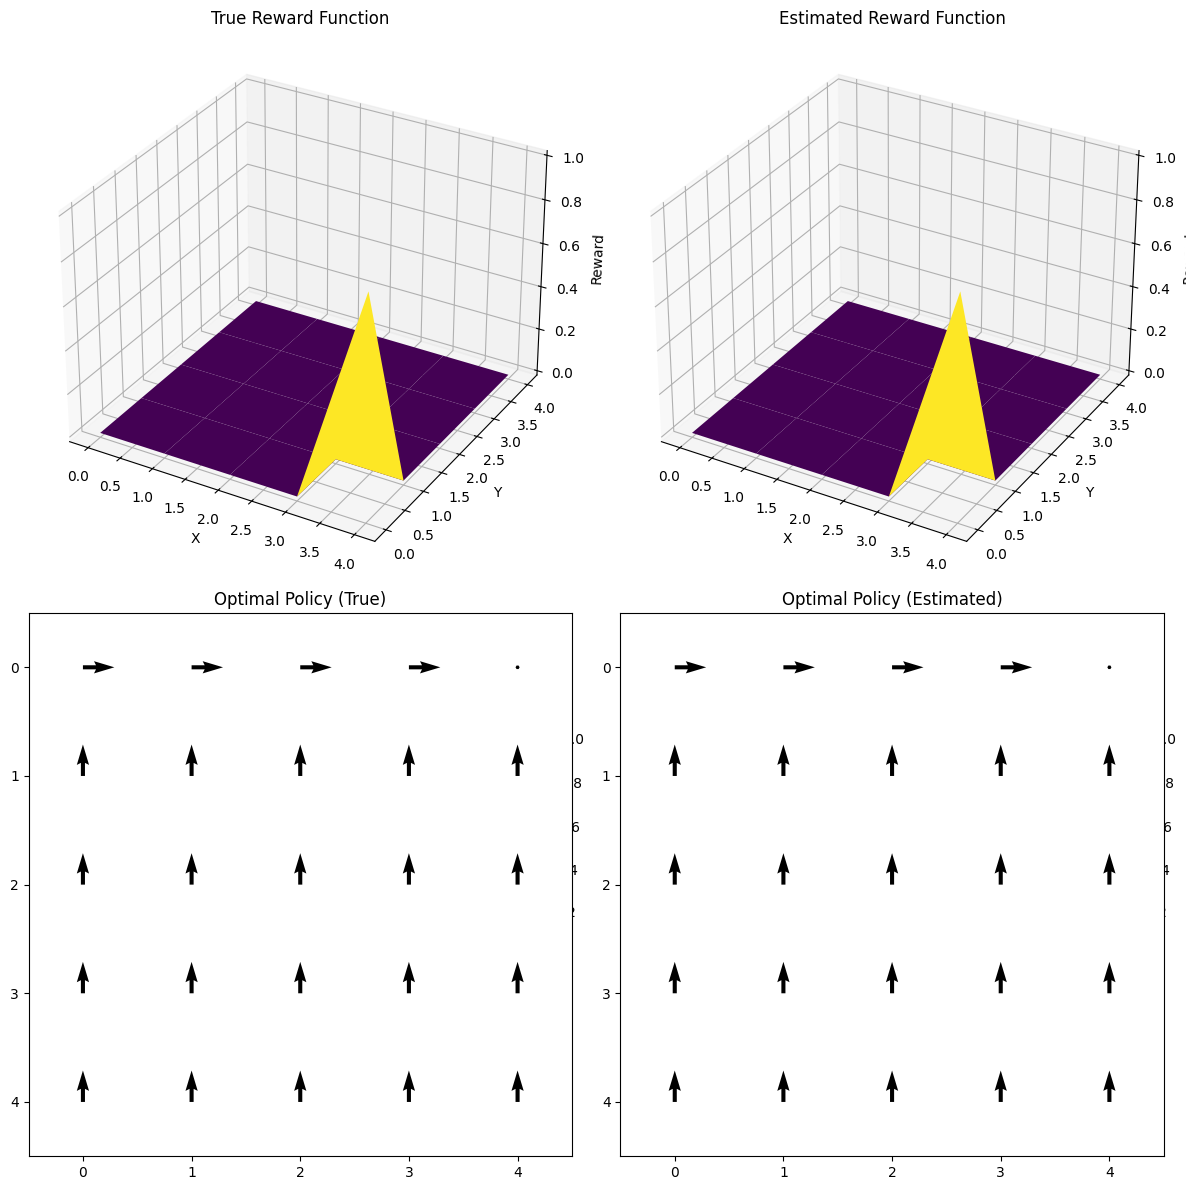

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Gridworld setup
grid_size = 5  # Change grid size to 5x5
N = grid_size * grid_size  # Total number of states
K = 5  # Actions: up, down, left, right, stay
gamma = 0.9  # Discount factor
Rmax = 1.0  # Maximum reward
lp_lambda = 1  # Regularization coefficient

actions = ['up', 'down', 'left', 'right', 'stay']
action_indices = {action: i for i, action in enumerate(actions)}

# Transition probability matrix with 30% noise
P = np.zeros((N, N, K))
noise_prob = 0.3

for s in range(N):
    x, y = divmod(s, grid_size)
    for a_idx, action in enumerate(actions):
        if action == 'up':
            next_x = x - 1
            next_y = y
        elif action == 'down':
            next_x = x + 1
            next_y = y
        elif action == 'left':
            next_x = x
            next_y = y - 1
        elif action == 'right':
            next_x = x
            next_y = y + 1
        elif action == 'stay':
            next_x = x
            next_y = y

        if 0 <= next_x < grid_size and 0 <= next_y < grid_size:
            next_s = next_x * grid_size + next_y
        else:
            next_s = s  # Stay in the same state if action leads out of bounds

        # Add noise: 30% chance of a random transition
        for noise_action in range(K):
            if noise_action == a_idx:
                P[s, next_s, noise_action] = 1.0 - noise_prob  # Intended action succeeds with 70% chance
            else:
                next_x, next_y = divmod(s, grid_size)  # Reset to original position
                if noise_action == 0:  # Up
                    next_x -= 1
                elif noise_action == 1:  # Down
                    next_x += 1
                elif noise_action == 2:  # Left
                    next_y -= 1
                elif noise_action == 3:  # Right
                    next_y += 1

                # Handle boundary conditions
                if 0 <= next_x < grid_size and 0 <= next_y < grid_size:
                    next_s_noise = next_x * grid_size + next_y
                else:
                    next_s_noise = s  # Stay in the same state if action leads out of bounds

                P[s, next_s_noise, noise_action] = noise_prob / (K - 1)  # Equal chance of random transitions

# Reward function setup
true_R = np.zeros(N)
goal_state = grid_size - 1  # Top-right corner (state corresponding to [grid_size - 1, grid_size - 1])
start_state = N - grid_size  # Bottom-left corner (state corresponding to [0, grid_size - 1])
true_R[goal_state] = 1.0  # Reward of 1 at the goal state

# Value iteration to find the optimal policy and value function
V_opt, opt_pi = value_iteration(N, K, true_R, P, gamma)

# Perform Inverse Reinforcement Learning using the optimal policy
estimated_R, V_est = finite_lp_irl(
    N, K, P, gamma, Rmax, opt_pi, lp_lambda
)

# Compute the estimated policy using the estimated rewards
_, est_pi = value_iteration(N, K, estimated_R, P, gamma)

# Reshape rewards for plotting
true_R_grid = true_R.reshape((grid_size, grid_size))
estimated_R_grid = estimated_R.reshape((grid_size, grid_size))

# Prepare for quiver plot data (Optimal Policy)
action_to_vector = {
    0: (0, 1),      # up
    1: (0, -1),     # down
    2: (-1, 0),     # left
    3: (1, 0),      # right
    4: (0, 0)       # stay
}

# Initialize the policy quiver data
U_true = np.zeros((grid_size, grid_size))
V_true = np.zeros((grid_size, grid_size))
U_estimated = np.zeros((grid_size, grid_size))
V_estimated = np.zeros((grid_size, grid_size))

# Fill quiver data for true policy
for s in range(N):
    x, y = divmod(s, grid_size)
    action = opt_pi[s]
    dx, dy = action_to_vector[action]
    U_true[x, y] = dx
    V_true[x, y] = dy

# Fill quiver data for estimated policy
for s in range(N):
    x, y = divmod(s, grid_size)
    action = est_pi[s]
    dx, dy = action_to_vector[action]
    U_estimated[x, y] = dx
    V_estimated[x, y] = dy

# Plot the 2x2 grid of True and Estimated Reward with Policies
X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
fig, axs = plt.subplots(2, 2, figsize=(12, 12), subplot_kw={'projection': '3d'})

# True Reward
ax1 = axs[0, 0]
ax1.plot_surface(X, Y, true_R_grid, cmap='viridis')
ax1.set_title('True Reward Function')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Reward')

# Estimated Reward
ax2 = axs[0, 1]
ax2.plot_surface(X, Y, estimated_R_grid, cmap='viridis')
ax2.set_title('Estimated Reward Function')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Reward')

# Plot the true policy (quiver plot)
ax3 = fig.add_subplot(2, 2, 3)
ax3.quiver(X, Y, U_true, V_true)
ax3.set_title('Optimal Policy (True)')
ax3.set_aspect('equal')
ax3.set_xlim(-0.5, grid_size - 0.5)
ax3.set_ylim(-0.5, grid_size - 0.5)
ax3.invert_yaxis()

# Plot the estimated policy (quiver plot)
ax4 = fig.add_subplot(2, 2, 4)
ax4.quiver(X, Y, U_estimated, V_estimated)
ax4.set_title('Optimal Policy (Estimated)')
ax4.set_aspect('equal')
ax4.set_xlim(-0.5, grid_size - 0.5)
ax4.set_ylim(-0.5, grid_size - 0.5)
ax4.invert_yaxis()

plt.tight_layout()
plt.show()


In [17]:
estimated_R_grid

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from finite_lp_irl import finite_lp_irl, value_iteration

# Grid parameters for cliff walking
grid_height, grid_width = 4, 12
N = grid_height * grid_width  # Total number of states
K = 4  # Actions: up, down, left, right
gamma = 0.9  # Discount factor
Rmax = 1.0  # Maximum reward (for normalization)
lp_lambda = 1  # Regularization coefficient

actions = ['up', 'down', 'left', 'right']
P = np.zeros((N, N, K))  # Transition matrix
noise_prob = 0.0  # No noise for deterministic behavior in this example

# Set up the grid transitions without noise
for s in range(N):
    x, y = divmod(s, grid_width)
    for a_idx, action in enumerate(actions):
        next_x, next_y = x + (action == 'down') - (action == 'up'), y + (action == 'right') - (action == 'left')
        next_s = s if not (0 <= next_x < grid_height and 0 <= next_y < grid_width) else next_x * grid_width + next_y
        P[s, next_s, a_idx] = 1.0

# Cliff setup and rewards
true_R = -np.ones(N)  # Default reward is -1 for every move

cliff_states = np.arange(grid_width + 1, 2 * grid_width)  # Cliff is between (1,1) to (1,10) on grid
true_R[cliff_states] = -100.0  # Falling off the cliff gives a reward of -100

start_state = grid_width * (grid_height - 1)  # Start state (bottom-left corner)
goal_state = grid_width * grid_height - 1  # Goal state (bottom-right corner)
true_R[goal_state] = 0.0  # Reaching the goal gives a reward of 0

# Value iteration to find the optimal policy and value function
V_opt, opt_pi = value_iteration(N, K, true_R, P, gamma)

# Perform Inverse Reinforcement Learning using the optimal policy
estimated_R, V_est = finite_lp_irl(N, K, P, gamma, Rmax, opt_pi, lp_lambda)

# Compute the estimated policy using the estimated rewards
_, est_pi = value_iteration(N, K, estimated_R, P, gamma)

# Reshape rewards for plotting
true_R_grid = true_R.reshape(grid_height, grid_width)
estimated_R_grid = estimated_R.reshape(grid_height, grid_width)

# Prepare for quiver plot data (Optimal Policy)
action_to_vector = {0: (0, 1), 1: (0, -1), 2: (-1, 0), 3: (1, 0)}

U_true = np.zeros((grid_height, grid_width))
V_true = np.zeros((grid_height, grid_width))
U_estimated = np.zeros((grid_height, grid_width))
V_estimated = np.zeros((grid_height, grid_width))

# Fill quiver data for true policy
for s in range(N):
    x, y = divmod(s, grid_width)
    U_true[x, y], V_true[x, y] = action_to_vector[opt_pi[s]]
    U_estimated[x, y], V_estimated[x, y] = action_to_vector[est_pi[s]]

# Plot the 2x2 grid of True and Estimated Reward with Policies
X, Y = np.meshgrid(np.arange(grid_width), np.arange(grid_height))
fig, axs = plt.subplots(2, 2, figsize=(12, 12), subplot_kw={'projection': '3d'})

# True Reward
ax1 = axs[0, 0]
ax1.plot_surface(X, Y, true_R_grid, cmap='viridis')
ax1.set_title('True Reward Function')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Reward')

# Estimated Reward
ax2 = axs[0, 1]
ax2.plot_surface(X, Y, estimated_R_grid, cmap='viridis')
ax2.set_title('Estimated Reward Function')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Reward')

# Plot the true policy (quiver plot)
ax3 = fig.add_subplot(2, 2, 3)
ax3.quiver(X, Y, U_true, V_true)
ax3.set_title('Optimal Policy (True)')
ax3.set_aspect('equal')
ax3.set_xlim(-0.5, grid_width - 0.5)
ax3.set_ylim(-0.5, grid_height - 0.5)
ax3.invert_yaxis()

# Plot the estimated policy (quiver plot)
ax4 = fig.add_subplot(2, 2, 4)
ax4.quiver(X, Y, U_estimated, V_estimated)
ax4.set_title('Optimal Policy (Estimated)')
ax4.set_aspect('equal')
ax4.set_xlim(-0.5, grid_width - 0.5)
ax4.set_ylim(-0.5, grid_height - 0.5)
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig('plots/cliff_walking_gridworld.png')
plt.close()


Linear Programming Problem Formulation:
-------------------------------------
Objective Function: Minimize -sum(z_s) + 1 * sum(R_s)
Number of Variables: 96
Number of Constraints: 384

Constraints:
1. z_s - drop_in_value(a, s) @ R <= 0, for all s, a != optimal_policy[s]
2. -drop_in_value(a, s) @ R <= 0, for all s, a
3. R_s <= 1.0, for all s
4. z_s >= 0, R_s >= 0, for all s
-------------------------------------

Solver Results:
---------------
Optimization succeeded.
Objective value: -1.9900000000000064
Number of iterations: 89
